<a href="https://colab.research.google.com/github/JorgeMarquezPiedra/Afluencia-Metrobus-Ciudad-de-Mexico-2010-a-2025-Python/blob/main/Afluencia_Metrobus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Afluencia en STC Metrobus

In [1]:
# Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Leer dataset simple
mb = pd.read_csv('afluenciamb_simple_01_2026.csv')
mb

,fecha,anio,mes,linea,afluencia
0,2005-07-26,2005,Julio,Línea 1,3032667.0
1,2005-07-26,2005,Julio,Línea 5,NaN
2,2005-07-26,2005,Julio,Línea 2,NaN
3,2005-07-26,2005,Julio,Línea 3,NaN
4,2005-07-26,2005,Julio,Línea 6,NaN
...,...,...,...,...,...
52460,2026-01-31,2026,Enero,Línea 3,134880.0
52461,2026-01-31,2026,Enero,Línea 4,93688.0
52462,2026-01-31,2026,Enero,Línea 5,177086.0
52463,2026-01-31,2026,Enero,Línea 6,134984.0


In [3]:
# Leer dataset desglosado
mb_desg = pd.read_csv('afluenciamb_desglosado_01_2026.csv')
mb_desg

,fecha,mes,anio,linea,tipo_pago,afluencia
0,2021-01-01,Enero,2021,Línea 1,Prepago,39122.0
1,2021-01-01,Enero,2021,Línea 1,Gratuidad,3528.0
2,2021-01-01,Enero,2021,Línea 2,Prepago,23669.0
3,2021-01-01,Enero,2021,Línea 2,Gratuidad,2532.0
4,2021-01-01,Enero,2021,Línea 3,Prepago,18229.0
...,...,...,...,...,...,...
25993,2026-01-29,Enero,2026,Línea 7,Gratuidad,4360.0
25994,2026-01-30,Enero,2026,Línea 7,Prepago,131252.0
25995,2026-01-30,Enero,2026,Línea 7,Gratuidad,5268.0
25996,2026-01-31,Enero,2026,Línea 7,Prepago,101605.0


In [4]:
# Ver valores únicos de linea
mb['linea'].unique()

array(['Línea 1', 'Línea 5', 'Línea 2', 'Línea 3', 'Línea 6', 'Línea 7',
       'Línea 4', 'linea 1', 'linea 2', 'linea 3', 'linea 4', 'linea 5',
       'linea 6', 'linea 7'], dtype=object)

In [5]:
# Ver valores únicos de linea
mb['mes'].unique()

array(['Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre',
       'Diciembre', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio'],
      dtype=object)

In [6]:
# Homogenizar valores de linea
mb['linea'] = mb['linea'].str.replace('linea', 'Línea', regex=False)

print("Valores únicos en 'linea' unificados:")
print(mb['linea'].unique())

Valores únicos en 'linea' unificados:
['Línea 1' 'Línea 5' 'Línea 2' 'Línea 3' 'Línea 6' 'Línea 7' 'Línea 4']


In [7]:
# Información del dataset
mb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52465 entries, 0 to 52464
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      52465 non-null  object 
 1   anio       52465 non-null  int64  
 2   mes        52465 non-null  object 
 3   linea      52465 non-null  object 
 4   afluencia  35238 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 2.0+ MB


In [8]:
# Convertir datos de fecha en datetime
mb['fecha'] = pd.to_datetime(mb['fecha'])

# Filtrar las fechas para que sean iguales o posteriores a '2005-07-01'
mb = mb[mb['fecha'] >= '2005-07-27']

In [9]:
# Estadísticas básicas
mb.describe()

,fecha,anio,afluencia
count,52458,52458.000000,35237.000000
mean,2015-10-29 11:59:59.999999744,2015.322391,166173.733788
min,2005-07-27 00:00:00,2005.000000,9.000000
25%,2010-09-12 00:00:00,2010.000000,82302.000000
50%,2015-10-29 12:00:00,2015.000000,136028.000000
75%,2020-12-15 00:00:00,2020.000000,205268.000000
max,2026-01-31 00:00:00,2026.000000,615838.000000
std,NaN,5.929622,116157.287999


##Distribución de la afluencia

/tmp/ipython-input-167/1360963917.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mb['afluencia_millones'] = mb['afluencia'] / 1_000_000


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

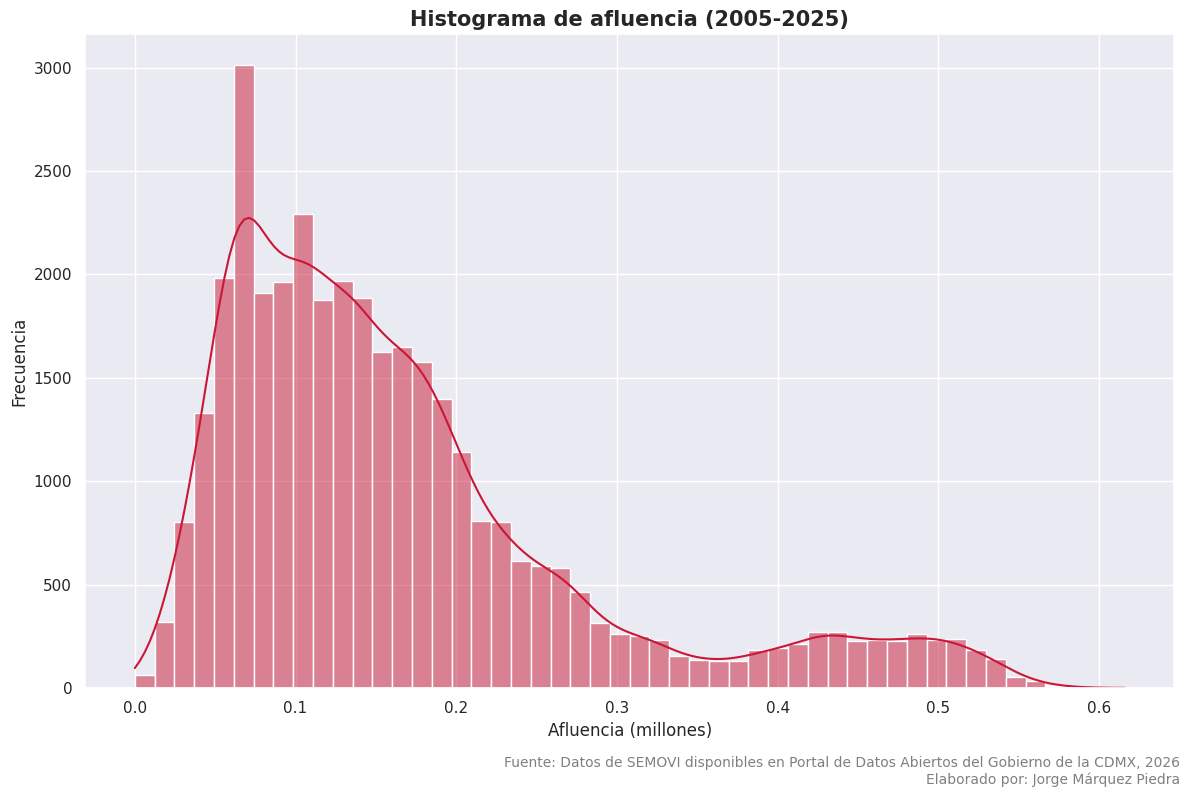

In [10]:
# Crear variable en millones
mb['afluencia_millones'] = mb['afluencia'] / 1_000_000

# Histograma de afluencia
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.histplot(mb['afluencia_millones'], bins = 50, kde = True, color = '#ca1735')
plt.title('Histograma de afluencia (2005-2025)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Afluencia (millones)')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.13)
plt.savefig('histograma_afluencia.png', dpi = 300)
plt

##Afluencia promedio por línea

In [11]:
import re

# Definir manera personalizada de ordenar 'linea'
def sort_lineas(linea_name):
    # Extraer la parte posterior a "Línea "
    match = re.match(r'Línea (\d+|[A-Z])', linea_name)
    if match:
        identifier = match.group(1)
        if identifier.isdigit():
            return (0, int(identifier)) # Ordenar número (ej., 1, 2, 3...)
        else:
            return (1, identifier) # Ordenar letras después de números (e.g., A, B...)
    return (2, linea_name)

# Define paleta de colores
linea_color_map = {
    'Línea 1': '#a7363c',
    'Línea 2': '#8a199d',
    'Línea 3': '#77990f',
    'Línea 4': '#f85102',
    'Línea 5': '#071f5f',
    'Línea 6': '#e51395',
    'Línea 7': '#176939'
}

# Ordenar las líneas usando la función personalizada
sorted_lines_for_plotting = sorted(linea_color_map.keys(), key=sort_lineas)

print("Color asignado para cada línea:")
for linea, color in linea_color_map.items():
    print(f"{linea}: {color}")

print("\nLineas ordenadas:")
print(sorted_lines_for_plotting)

Color asignado para cada línea:
Línea 1: #a7363c
Línea 2: #8a199d
Línea 3: #77990f
Línea 4: #f85102
Línea 5: #071f5f
Línea 6: #e51395
Línea 7: #176939

Lineas ordenadas:
['Línea 1', 'Línea 2', 'Línea 3', 'Línea 4', 'Línea 5', 'Línea 6', 'Línea 7']


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

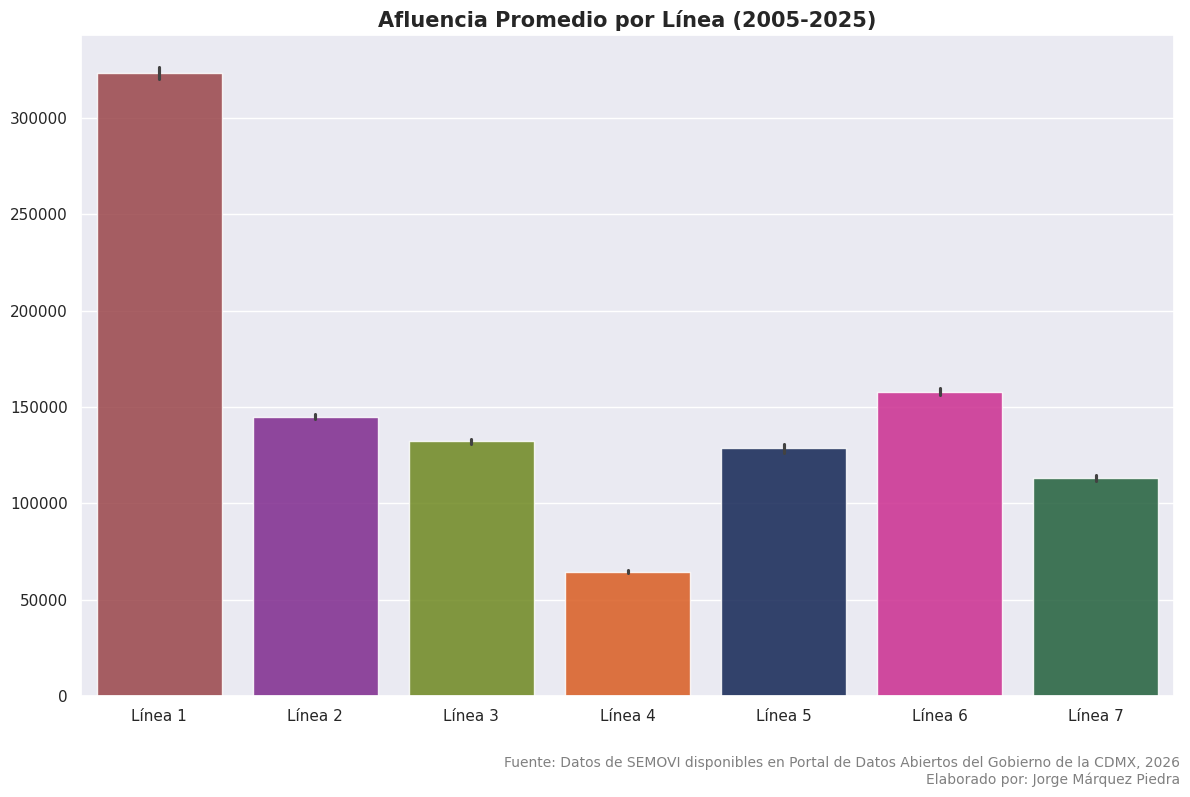

In [12]:
# Gráfica de afluencia promedio por línea
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.barplot(
    data = mb,
    x = 'linea',
    y = 'afluencia',
    estimator = 'mean',
    hue = 'linea',
    palette = linea_color_map,
    alpha = 0.85,
    order = sorted_lines_for_plotting,
    legend = False
)
plt.title('Afluencia Promedio por Línea (2005-2025)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks()
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('afluencia_promedio_por_linea.png', dpi = 300)
plt

##Variables de tiempo

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

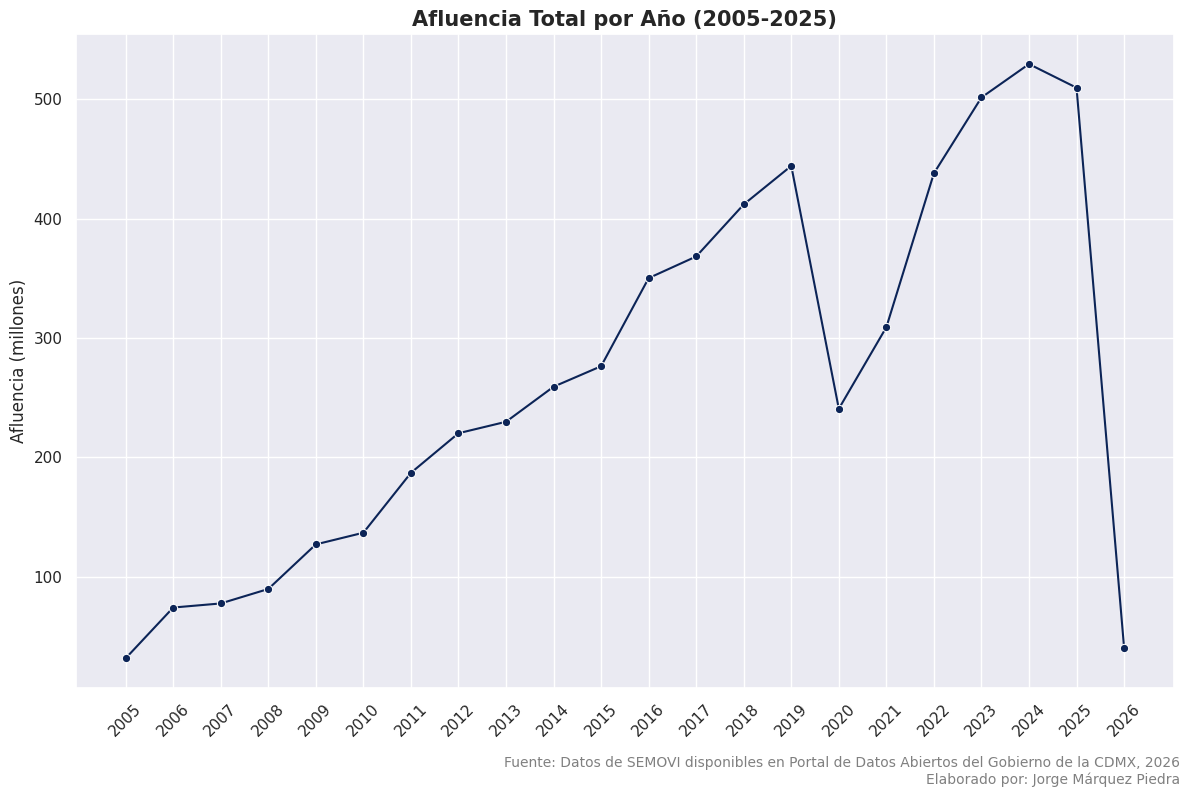

In [13]:
# Afluencia por año
afluencia_por_anio = mb.groupby('anio')['afluencia'].sum().reset_index()

# Convertir a millones
afluencia_por_anio['afluencia_millones'] = afluencia_por_anio['afluencia'] / 1_000_000

# Gráfico de línea de afluencia por año
plt.figure(figsize=(12, 8))
sns.lineplot(data = afluencia_por_anio, x = 'anio', y = 'afluencia_millones', marker = 'o', color = '#0c2457')
plt.title('Afluencia Total por Año (2005-2025)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (millones)')
plt.xticks(afluencia_por_anio['anio'].unique(), rotation=45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.13)
plt.savefig('afluencia_total_por_año.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

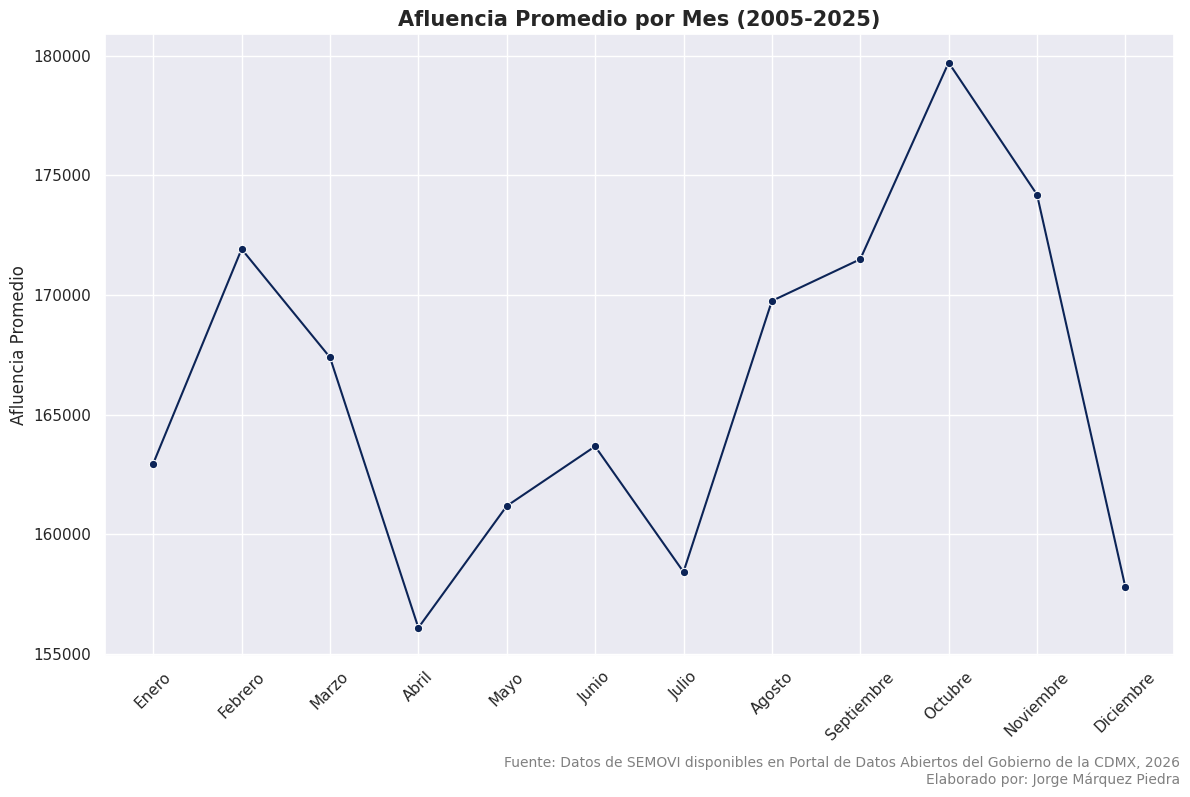

In [14]:
# Afluencia promedio por mes
afluencia_por_mes = mb.groupby('mes')['afluencia'].mean().reset_index()

# Definir el orden correcto de meses
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Ordenar el dataframe usando el orden de meses
afluencia_por_mes['mes'] = pd.Categorical(afluencia_por_mes['mes'], categories = orden_meses, ordered = True)
afluencia_por_mes = afluencia_por_mes.sort_values('mes')

# Gráfico de línea de afluencia promedio por mes
plt.figure(figsize=(12, 8))
sns.lineplot(data = afluencia_por_mes, x = 'mes', y = 'afluencia', marker = 'o', color = '#0c2457')
plt.title('Afluencia Promedio por Mes (2005-2025)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia Promedio')
plt.xticks(rotation=45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.17)
plt.savefig('afluencia_por_mes.png', dpi = 300)
plt

In [15]:
# Traducir los días de inglés a español
day_name_mapping = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

# Crear los días de la semana en el dataframe desglosado y sustituir con nombres en español
mb['dia_semana'] = mb['fecha'].dt.day_name()
mb['dia_semana'] = mb['dia_semana'].map(day_name_mapping)

print(mb['dia_semana'].unique())
mb

['Miércoles' 'Jueves' 'Viernes' 'Sábado' 'Domingo' 'Lunes' 'Martes']


/tmp/ipython-input-167/3710398760.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mb['dia_semana'] = mb['fecha'].dt.day_name()
/tmp/ipython-input-167/3710398760.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mb['dia_semana'] = mb['dia_semana'].map(day_name_mapping)


,fecha,anio,mes,linea,afluencia,afluencia_millones,dia_semana
7,2005-07-27,2005,Julio,Línea 1,230465.0,0.230465,Miércoles
8,2005-07-27,2005,Julio,Línea 6,NaN,NaN,Miércoles
9,2005-07-27,2005,Julio,Línea 3,NaN,NaN,Miércoles
10,2005-07-27,2005,Julio,Línea 2,NaN,NaN,Miércoles
11,2005-07-27,2005,Julio,Línea 5,NaN,NaN,Miércoles
...,...,...,...,...,...,...,...
52460,2026-01-31,2026,Enero,Línea 3,134880.0,0.134880,Sábado
52461,2026-01-31,2026,Enero,Línea 4,93688.0,0.093688,Sábado
52462,2026-01-31,2026,Enero,Línea 5,177086.0,0.177086,Sábado
52463,2026-01-31,2026,Enero,Línea 6,134984.0,0.134984,Sábado


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

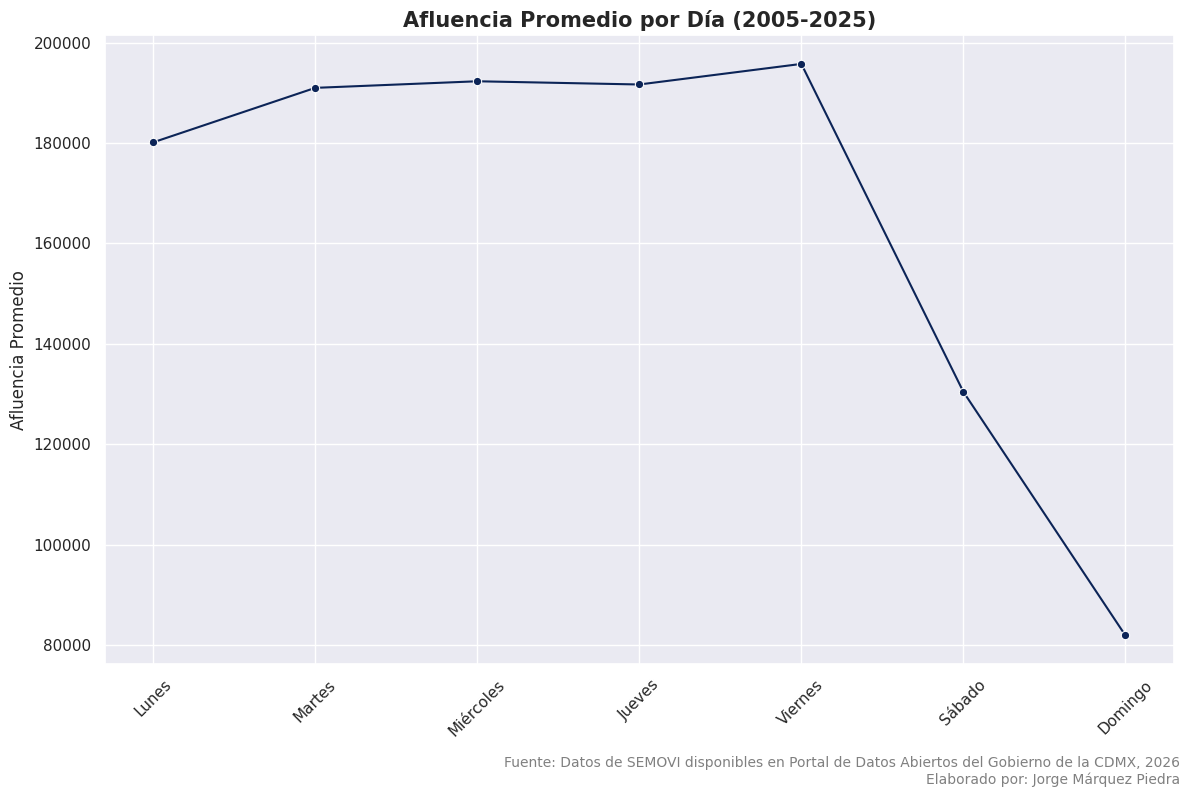

In [16]:
# Afluencia promedio por día
afluencia_por_dia = mb.groupby('dia_semana')['afluencia'].mean().reset_index()

# Definir el orden correcto de meses
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# Ordenar el dataframe usando el orden de meses
afluencia_por_dia['dia_semana'] = pd.Categorical(afluencia_por_dia['dia_semana'], categories = orden_dias, ordered = True)
afluencia_por_dia = afluencia_por_dia.sort_values('dia_semana')

# Gráfico de línea de afluencia promedio por mes
plt.figure(figsize=(12, 8))
sns.lineplot(data = afluencia_por_dia, x = 'dia_semana', y = 'afluencia', marker = 'o', color = '#0c2457')
plt.title('Afluencia Promedio por Día (2005-2025)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia Promedio')
plt.xticks(rotation=45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.16)
plt.savefig('afluencia_por_dia.png', dpi = 300)
plt

##Variabilidad de afluencia por día

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

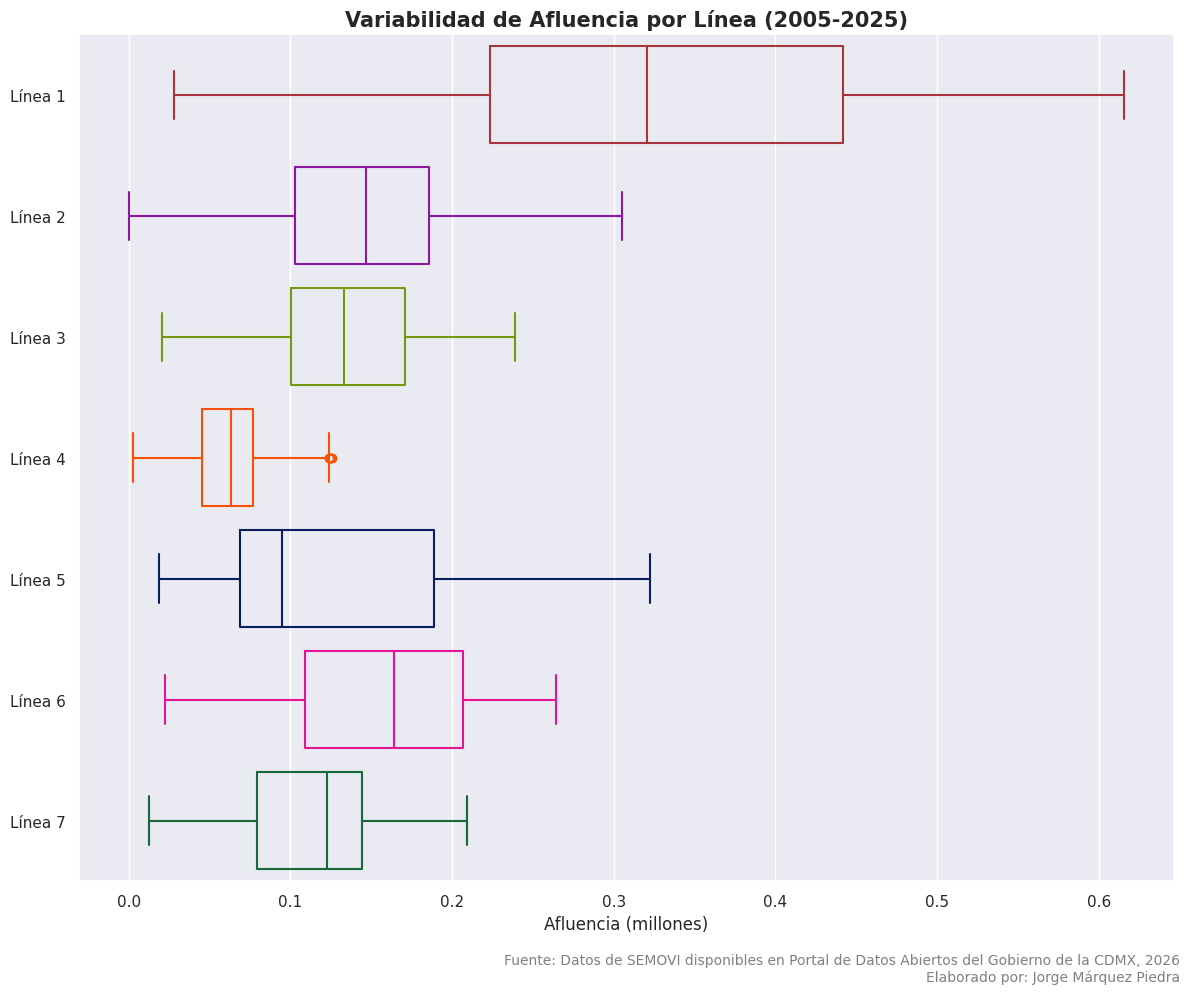

In [17]:
# Boxplot de afluencia por estación
plt.figure(figsize=(12, 10))
sns.set_theme()
sns.boxplot(
    data = mb,
    x = 'afluencia_millones',
    y = 'linea',
    hue = 'linea',
    fill = False,
    palette = linea_color_map,
    order = sorted_lines_for_plotting,
    legend = False)
plt.title('Variabilidad de Afluencia por Línea (2005-2025)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Afluencia (millones)')
plt.ylabel(None)
plt.xticks()
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.11)
plt.savefig('boxplot_por_linea.png', dpi = 300)
plt

##Heatmap año vs mes

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

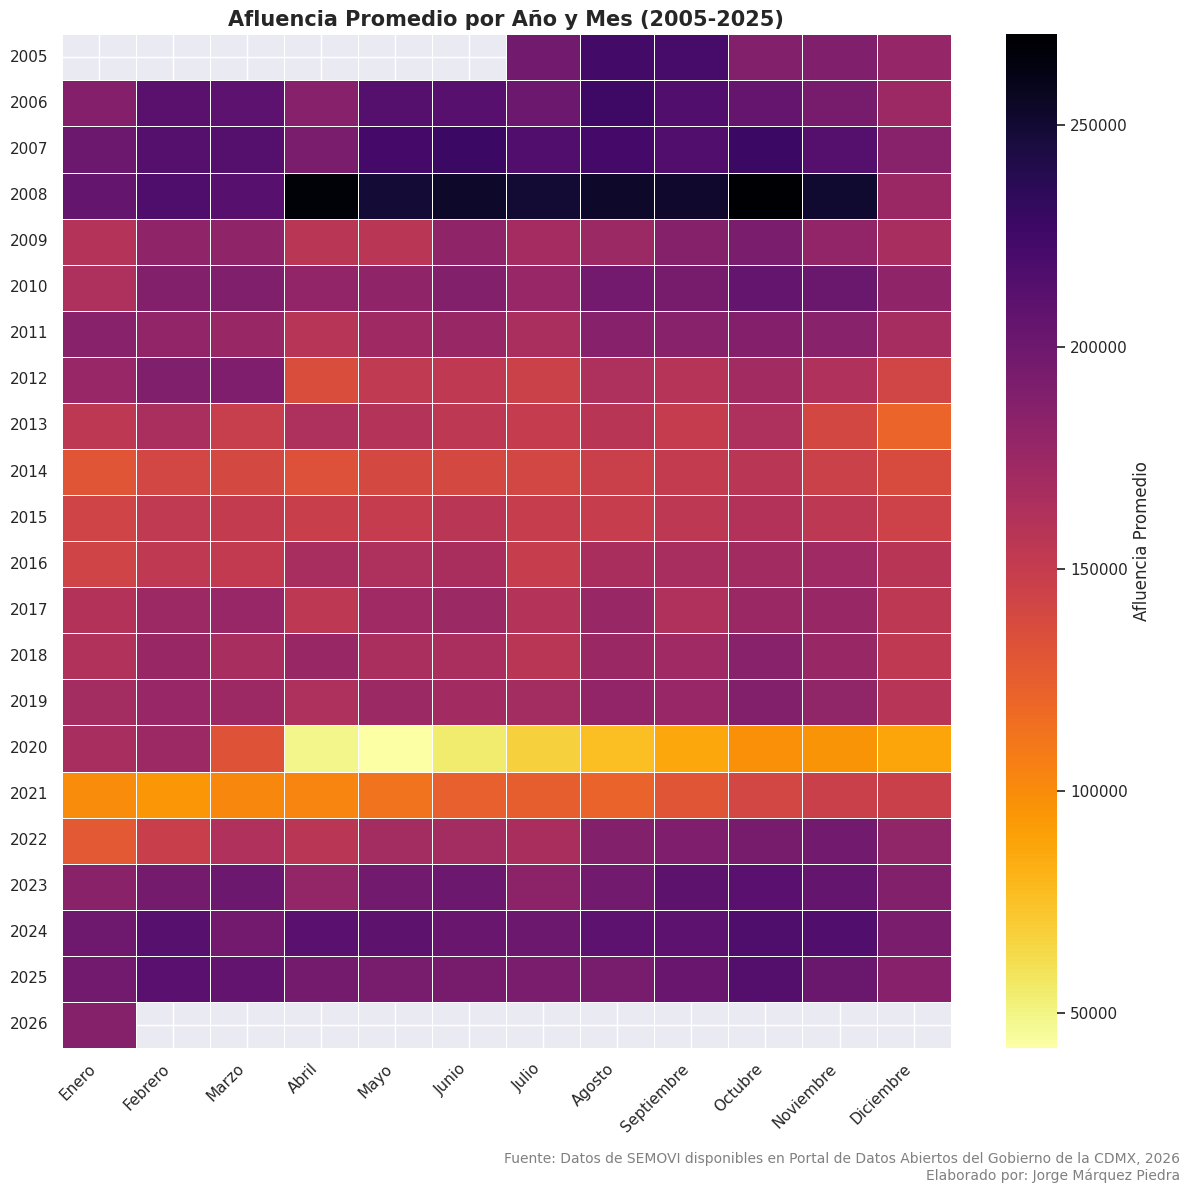

In [18]:
pivot = mb.pivot_table(values='afluencia', index='anio', columns='mes', aggfunc='mean')

# Ordenar los meses para el mapa
pivot = pivot[orden_meses]

plt.figure(figsize=(12, 12))
sns.set_theme()
sns.heatmap(pivot, cmap = "inferno_r", fmt = ".0f", linewidths = .5, cbar_kws = {'label': 'Afluencia Promedio'})
plt.title('Afluencia Promedio por Año y Mes (2005-2025)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('afluencia_heatmap_anio_mes.png', dpi = 300)
plt